### 1. PROBLEM STATEMENT

The goal of this project is to build a machine learning model that can detect fraudulent banking transactions based on customer behavior, transaction patterns, and risk indicators.

### 2. LOAD LIBRARIES AND DATA

In [2]:
import warnings
import itertools
import random

#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mn

In [3]:
fraud=pd.read_csv("FraudShield_Banking_Data.csv")
fraud.head()

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


In [4]:
fraud.shape

(50000, 25)

In [5]:
fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  str    
 4   Transaction_Date                       49997 non-null  str    
 5   Transaction_Type                       49996 non-null  str    
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  str    
 8   Transaction_Location                   49994 non-null  str    
 9   Customer_Home_Location                 49996 non-null  str    
 10  Distance_From_Home                     49998 non-null  float64
 11  Device_ID    

In [6]:
#Removing irrelevant columns
#The ID'S columnS is are irrelevant.They are identifiers and carry no predictive meaning
fraud =fraud.drop(columns=[
"Transaction_ID",
"Customer_ID",
"Merchant_ID",
"Device_ID",
"IP_Address"
])

### Cleaning Target Variable

In [7]:
fraud.isnull().sum().sort_values(ascending=False)

Failed_Transaction_Count                 11
Transaction_Amount (in Million)           9
Merchant_Category                         9
Transaction_Time                          9
Avg_Transaction_Amount (in Million)       9
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Transaction_Location                      6
Weekly_Transaction_Count                  5
Is_New_Merchant                           5
Is_International_Transaction              4
Transaction_Type                          4
Customer_Home_Location                    4
Fraud_Label                               4
Max_Transaction_Last_24h (in Million)     4
Transaction_Date                          3
Unusual_Time_Transaction                  3
Card_Type                                 3
Previous_Fraud_Count                      3
Distance_From_Home                        2
dtype: int64

In [13]:
fraud.dropna(subset=['Fraud_Label'], inplace=True)

In [89]:
# Convert target to numeric
y = fraud['Fraud_Label'].map({'Fraud': 1, 'Normal': 0})
X = fraud.drop('Fraud_Label', axis=1)

In [90]:
# Convert time
X['Transaction_Date'] = pd.to_datetime(X['Transaction_Date'])
X['Transaction_Time'] = pd.to_datetime(X['Transaction_Time'])

C:\Users\mburu\AppData\Local\Temp\ipykernel_9520\2364772293.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Transaction_Time'] = pd.to_datetime(X['Transaction_Time'])


OUTLIERS

In [91]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

C:\Users\mburu\AppData\Local\Temp\ipykernel_9520\197916445.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns


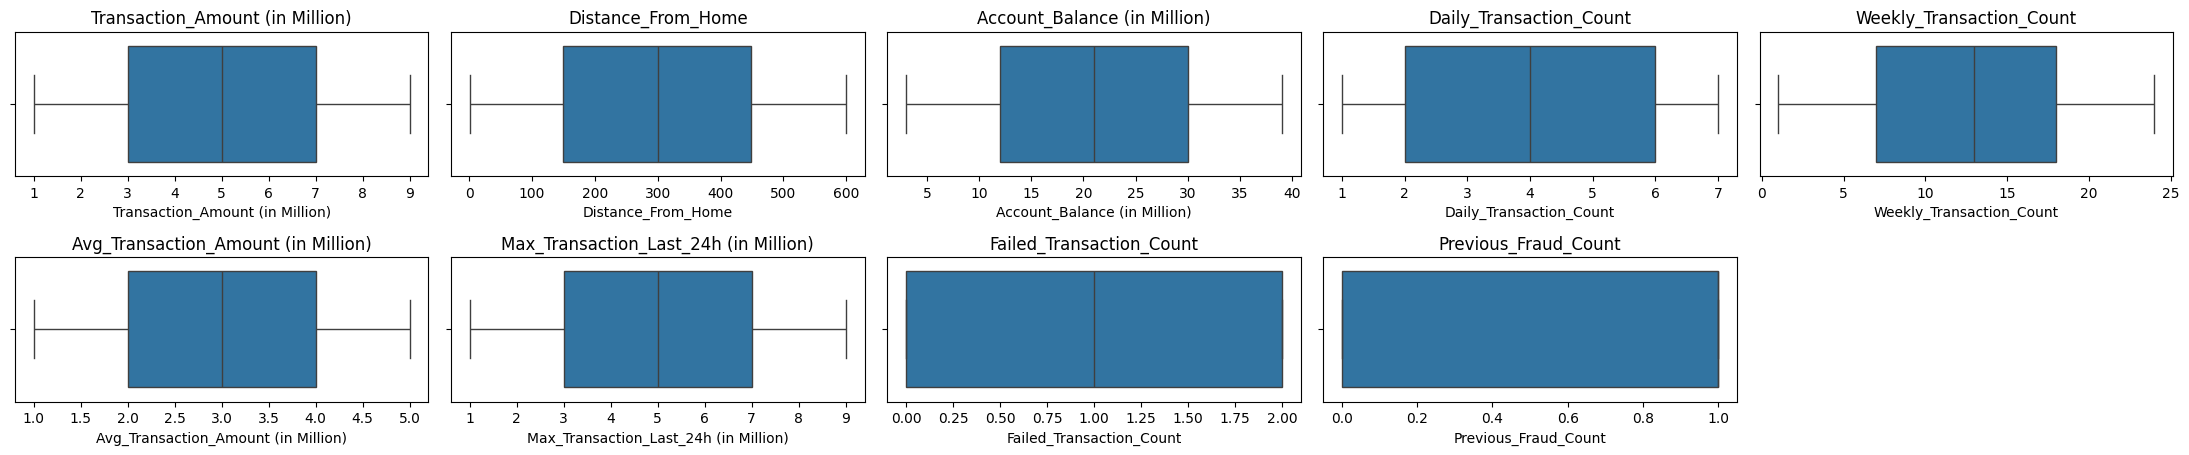

In [52]:
fig = plt.figure(figsize=(22,20))

for i in range(len(num_cols)):
    ax = fig.add_subplot(9, 5, i+1)
    sns.boxplot(x=X[num_cols].iloc[:, i], ax=ax)
    ax.set_title(num_cols[i])

plt.tight_layout()
plt.show()

The dataset shows no outliers and this strongly suggests the dataset is synthetic or pre-cleaned because in In real financial datasets, we normally see Large transaction outliers,extremely skewed spending behavior, heavy-tailed distributions.

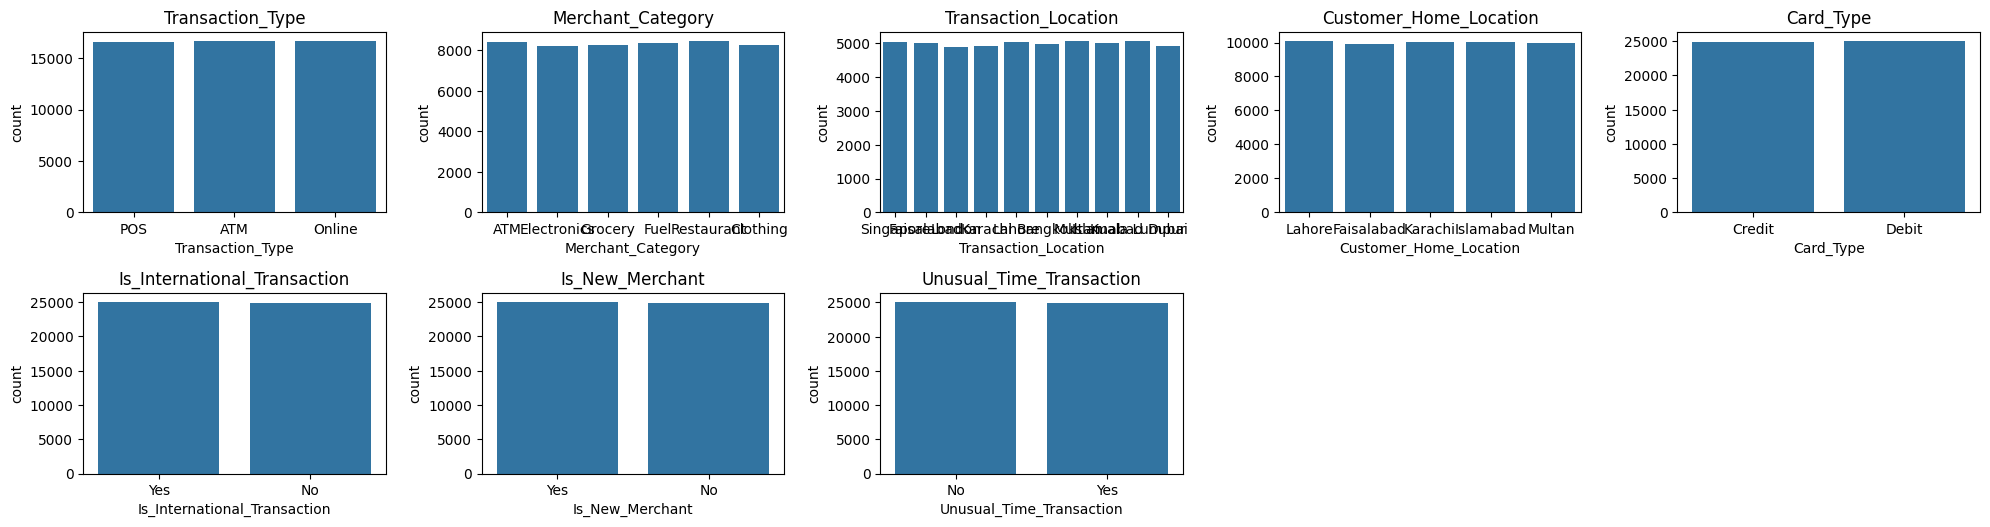

In [53]:
fig = plt.figure(figsize=(20,18))

for i in range(len(cat_cols)):
    ax = fig.add_subplot(7, 5, i+1)
    sns.countplot(x=X[cat_cols].iloc[:, i], ax=ax)
    ax.set_title(cat_cols[i])

plt.tight_layout()
plt.show()

CORRELATION

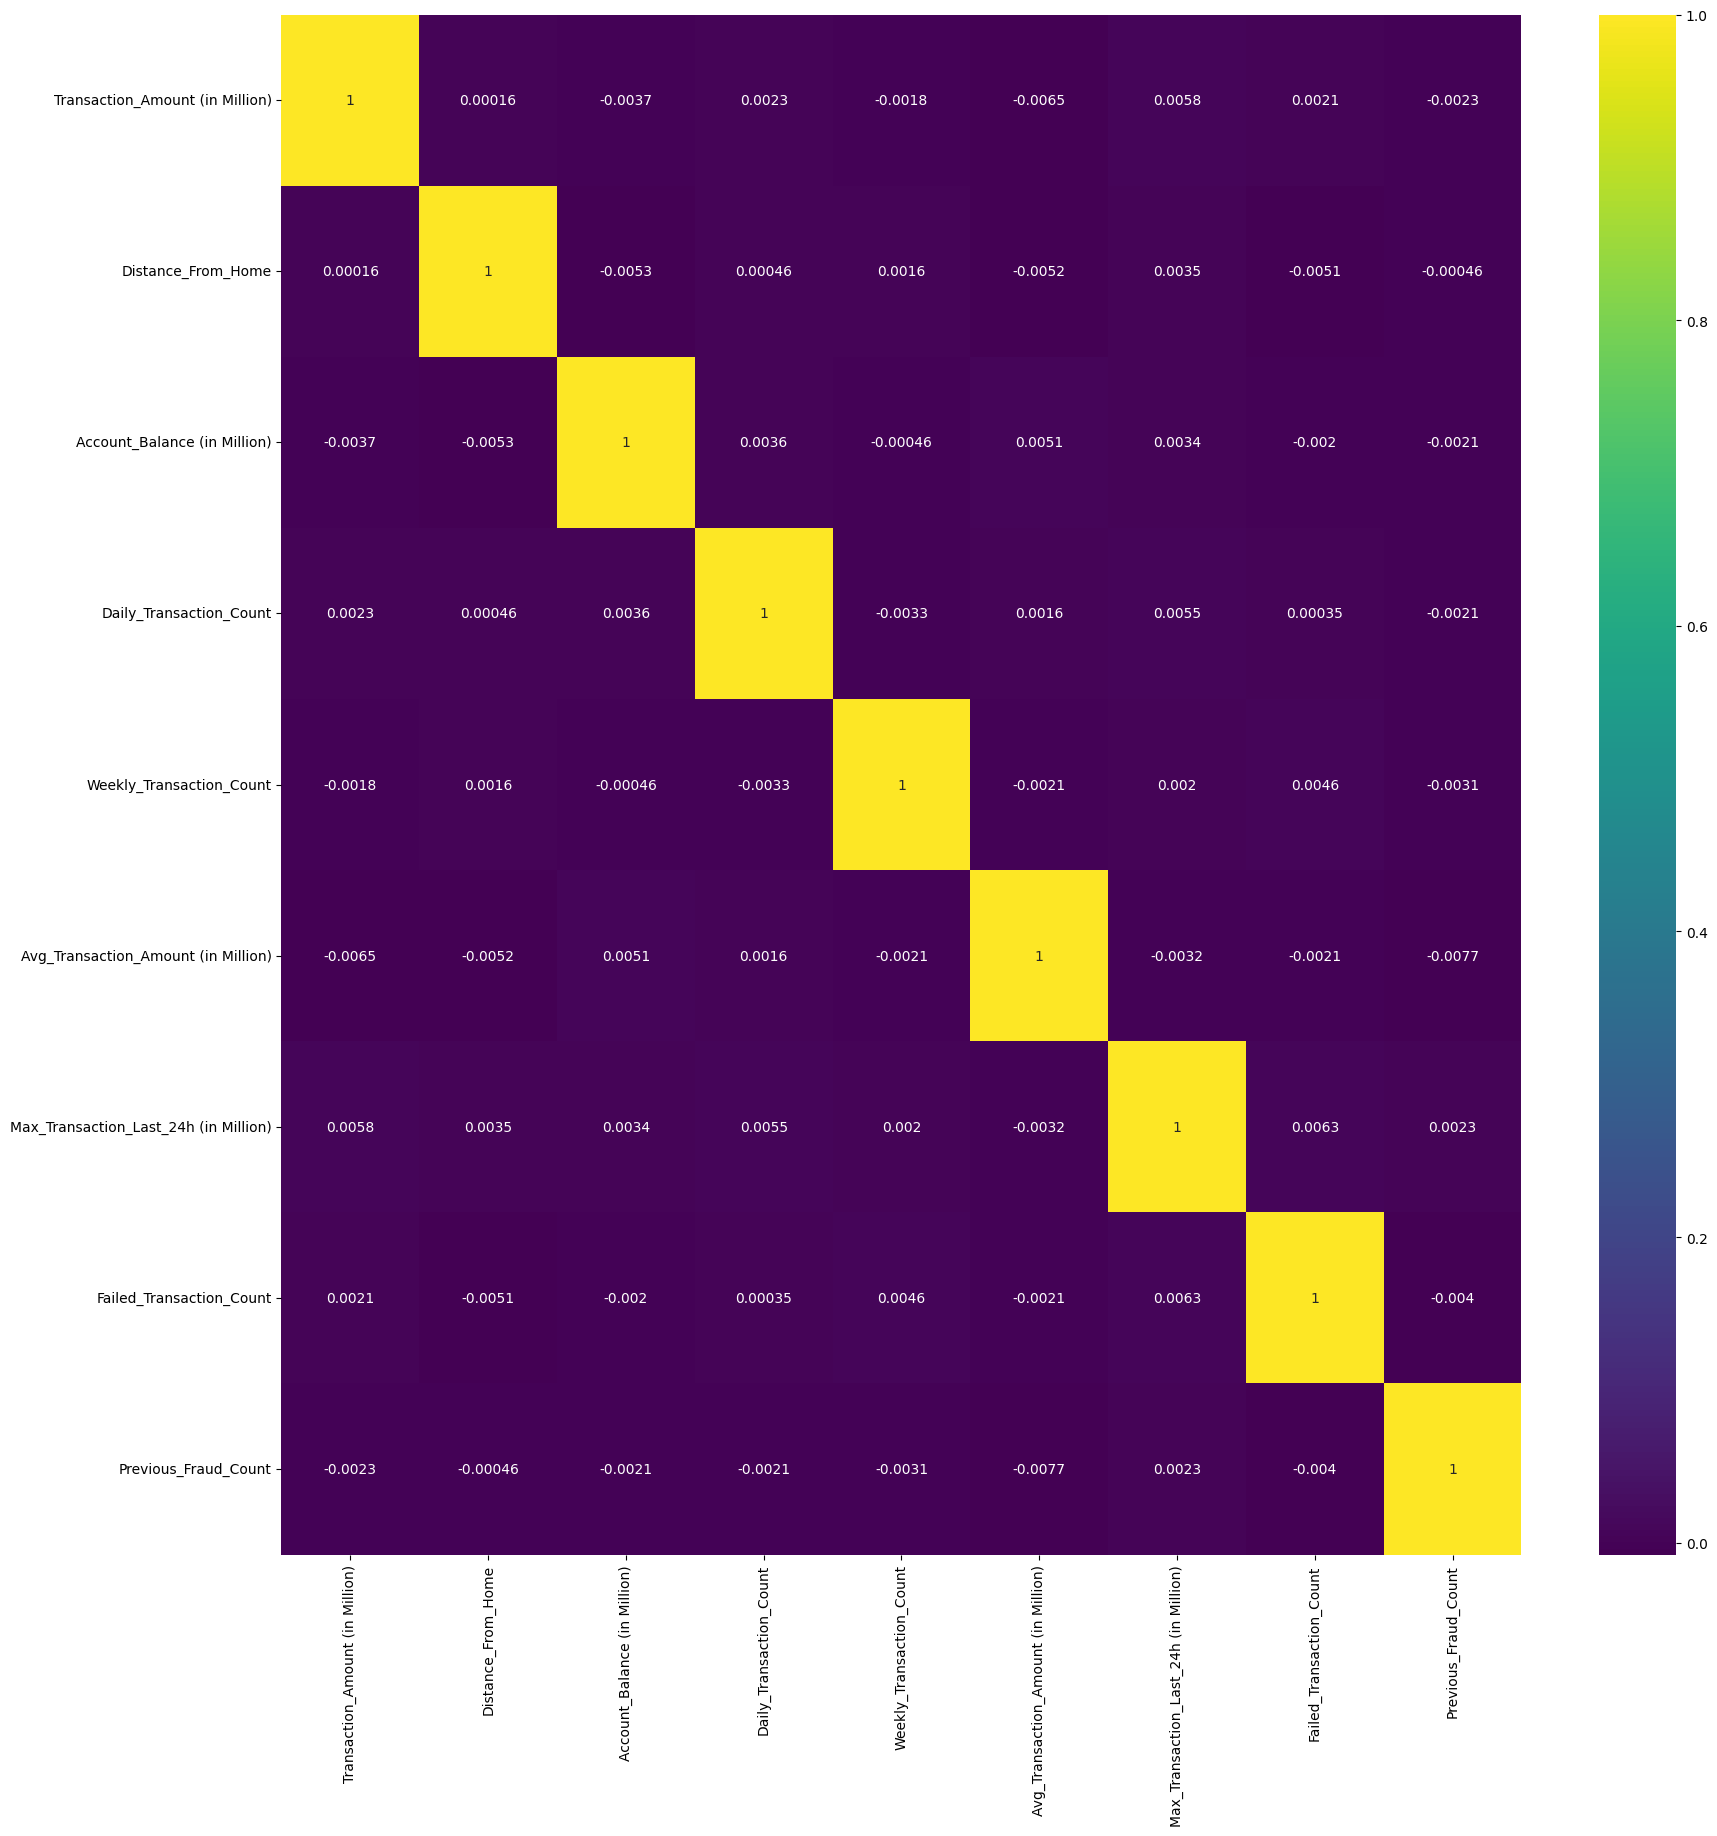

In [92]:
plt.figure(figsize=(20,20))
sns.heatmap(X[num_cols].corr(), annot=True, cmap="viridis")
plt.show()

### TRAIN-TEST SPLIT

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### EDA ON TRAINING DATASET

In [94]:
X_train.isnull().sum().sort_values(ascending=False)

Transaction_Time                         9
Failed_Transaction_Count                 9
Daily_Transaction_Count                  9
Avg_Transaction_Amount (in Million)      8
Transaction_Amount (in Million)          7
Account_Balance (in Million)             7
Merchant_Category                        7
Weekly_Transaction_Count                 5
Is_New_Merchant                          5
Transaction_Location                     5
Is_International_Transaction             4
Transaction_Type                         4
Max_Transaction_Last_24h (in Million)    4
Customer_Home_Location                   4
Transaction_Date                         3
Unusual_Time_Transaction                 3
Card_Type                                3
Distance_From_Home                       2
Previous_Fraud_Count                     2
dtype: int64

In [95]:
#percentage missingness
missing=X.isnull().sum()
percentage=(missing/len(X))*100

missing_table=pd.DataFrame({
    "Missing":missing,
    "Percentage":percentage
})

missing_table=missing_table[missing_table["Missing"]>0]
missing_table.sort_values('Percentage',ascending=False)

,Missing,Percentage
Failed_Transaction_Count,11,0.022002
Transaction_Time,9,0.018001
Transaction_Amount (in Million),9,0.018001
Avg_Transaction_Amount (in Million),9,0.018001
Merchant_Category,9,0.018001
Account_Balance (in Million),9,0.018001
Daily_Transaction_Count,9,0.018001
Transaction_Location,6,0.012001
Weekly_Transaction_Count,5,0.010001
Is_New_Merchant,5,0.010001


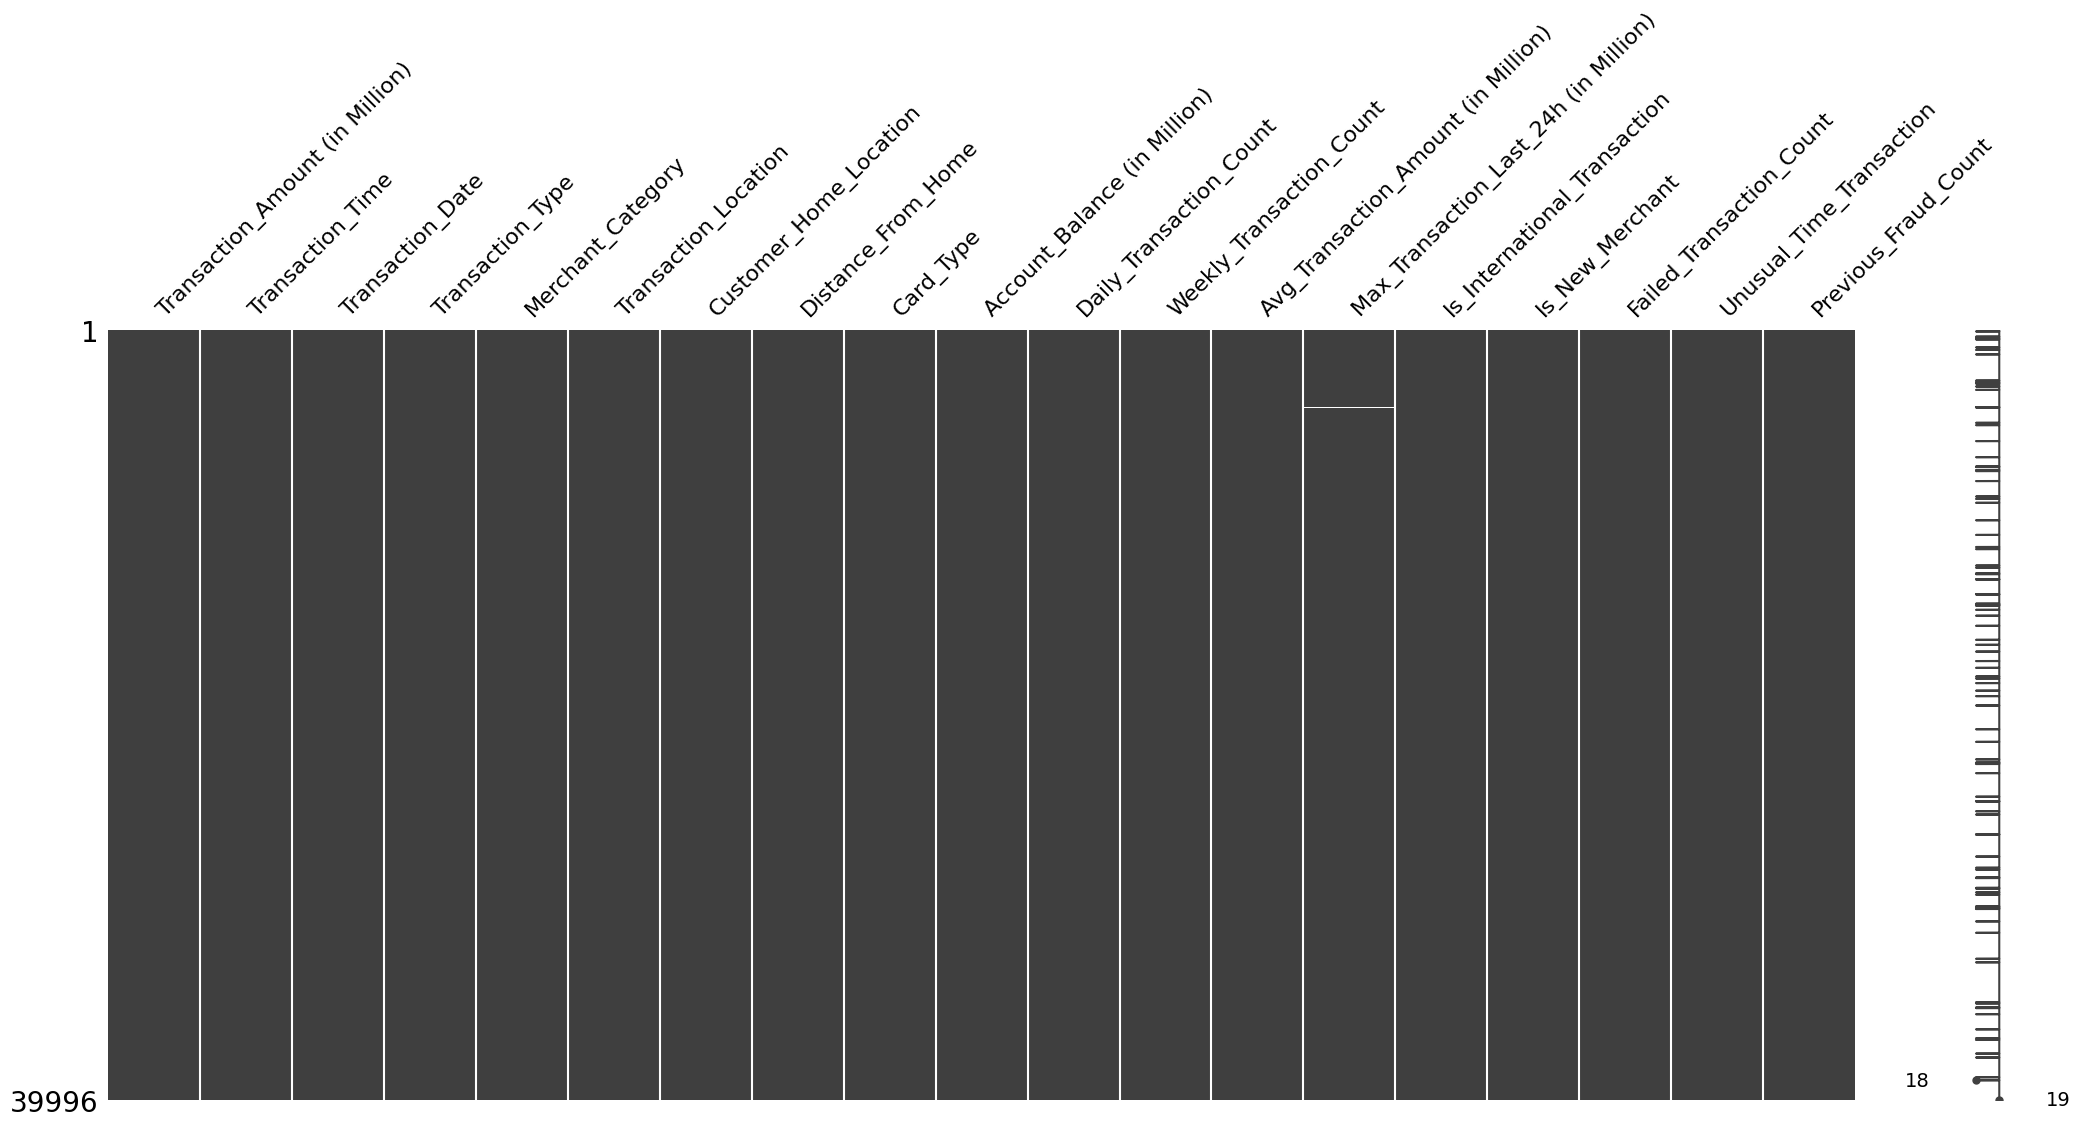

In [96]:
# Missing values
X_train.isnull().sum().sort_values(ascending=False)

mn.matrix(X_train)
plt.show()

### FEATURE ENGINEERING

##### Extract Time-Based Features

In [100]:
# Extract hour (0–23)
X_train["Transaction_Hour"] = X_train["Transaction_Time"].dt.hour

# Extract day of week (0=Monday, 6=Sunday)
X_train["Transaction_Day"] = X_train["Transaction_Date"].dt.dayofweek

# Extract month
X_train["Transaction_Month"] = X_train["Transaction_Date"].dt.month

We are trying to find out At what hour do frauds happen?Are frauds more common on weekends?Are there monthly trends?

Fraud patterns are often time based, transactions happening late night are suspicious while those hapening during weekends are prone to less monitoring

Create Night Transaction Flag

In [101]:
X_train["Night_Transaction"] = X_train["Transaction_Hour"].apply(
    lambda x: 1 if x >= 22 or x <= 5 else 0
)

Fraudsters often operate at night when users are asleep and this feature helps the model detect that behavior

In [102]:
# Drop Original Date Columns
X_train.drop(columns=["Transaction_Time", "Transaction_Date"], inplace=True)

# we droped them because models dont understand raw datetime well

##### BEHAVIORAL FEATURES

Transaction Deviation

In [103]:
X_train["Transaction_Deviation"] = (
    X_train["Transaction_Amount (in Million)"] /
    X_train["Avg_Transaction_Amount (in Million)"]
)

This helps check whether a transaction is unusually large compared to normal.
Fraud transactions are often much higher than usual spending

Transaction Velocity

In [104]:
X_train["Transaction_Velocity"] = (
    X_train["Daily_Transaction_Count"] /
    X_train["Weekly_Transaction_Count"]
)

Helps check the frequecy of transactions. Whether a user is transacting more today compared to other days.
Fraudsters often make many transactions quickly

Transaction vs Balance

In [105]:
X_train["Transaction_Balance_Ratio"] = (
    X_train["Max_Transaction_Last_24h (in Million)"] /
    X_train["Account_Balance (in Million)"]
)

Checking whether the transaction is too big compared to account balance.
Fraud often involves draining accounts

Distance Risk

In [106]:
X_train["Distance_Risk"] = (X_train["Distance_From_Home"] > 200).astype(int)

Checking to see whether the transaction is occuring far away or close to the user.Fraud often occurs in unusual locations

Fraud History

In [107]:
X_train["Fraud_History"] = (
    X_train["Previous_Fraud_Count"] +
    X_train["Failed_Transaction_Count"]
)

Checking whether this user have a risky history.By checking the past behaviour, we are able to predict the future.

Log Transformation (Normalize Amount)

In [108]:
X_train["Log_Transaction_Amount"] = np.log1p(
    X_train["Transaction_Amount (in Million)"]
)

Here, we are reducing the effect of very large transactions so that our data may not be skewed thus helping the model perform better.

Amount vs Balance Ratio

In [109]:
X_train["Amount_to_Balance"] = (
    X_train["Transaction_Amount (in Million)"] /
    (X_train["Account_Balance (in Million)"] + 1)
)

This helps detect unususally large withdrawals

Transactions per Hour

In [110]:
X_train["Txn_per_hour"] = X_train["Daily_Transaction_Count"] / 24

Average activity level so as to detect fraus

High Risk Combination

In [111]:
X_train["High_Risk_Combo"] = (
    (X_train["Night_Transaction"] == 1) &
    (X_train["Distance_Risk"] == 1)
).astype(int)

Is it BOTH night AND far from home?

This is a very strong fraud signal

Feature Engineering on test data

To ensure consistency. The model must see the same features during training and testing. Any transformation applied to training data must also be applied to test data to avoid data leakage and ensure reliable predictions

In [112]:

# Extract Time Features
X_test["Transaction_Hour"] = X_test["Transaction_Time"].dt.hour
X_test["Transaction_Day"] = X_test["Transaction_Date"].dt.dayofweek
X_test["Transaction_Month"] = X_test["Transaction_Date"].dt.month



# Night Transaction 
X_test["Night_Transaction"] = X_test["Transaction_Hour"].apply(
    lambda x: 1 if x >= 22 or x <= 5 else 0
)



#  Drop Original Columns
X_test.drop(columns=["Transaction_Time", "Transaction_Date"], inplace=True)


#  Transaction Deviation
X_test["Transaction_Deviation"] = (
    X_test["Transaction_Amount (in Million)"] /
    X_test["Avg_Transaction_Amount (in Million)"]
)



# Transaction Velocity

X_test["Transaction_Velocity"] = (
    X_test["Daily_Transaction_Count"] /
    X_test["Weekly_Transaction_Count"]
)



# Transaction vs Balance
X_test["Transaction_Balance_Ratio"] = (
    X_test["Max_Transaction_Last_24h (in Million)"] /
    X_test["Account_Balance (in Million)"]
)



# Distance Risk
X_test["Distance_Risk"] = (
    X_test["Distance_From_Home"] > 200
).astype(int)



# Fraud History

X_test["Fraud_History"] = (
    X_test["Previous_Fraud_Count"] +
    X_test["Failed_Transaction_Count"]
)



# Log Transformation
X_test["Log_Transaction_Amount"] = np.log1p(
    X_test["Transaction_Amount (in Million)"]
)



# Amount to Balance Ratio
X_test["Amount_to_Balance"] = (
    X_test["Transaction_Amount (in Million)"] /
    (X_test["Account_Balance (in Million)"] + 1)
)


#  Transactions per Hour
X_test["Txn_per_hour"] = (
    X_test["Daily_Transaction_Count"] / 24
)



#  High Risk Combination

X_test["High_Risk_Combo"] = (
    (X_test["Night_Transaction"] == 1) &
    (X_test["Distance_Risk"] == 1)
).astype(int)

In [113]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 39996 entries, 27986 to 14734
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_Amount (in Million)        39996 non-null  float64
 1   Transaction_Type                       39992 non-null  str    
 2   Merchant_Category                      39989 non-null  str    
 3   Transaction_Location                   39991 non-null  str    
 4   Customer_Home_Location                 39992 non-null  str    
 5   Distance_From_Home                     39996 non-null  float64
 6   Card_Type                              39993 non-null  str    
 7   Account_Balance (in Million)           39996 non-null  float64
 8   Daily_Transaction_Count                39996 non-null  float64
 9   Weekly_Transaction_Count               39996 non-null  float64
 10  Avg_Transaction_Amount (in Million)    39996 non-null  float64
 11  Max_Transactio

### PREPROCESSING

In [114]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(include=np.number).columns

C:\Users\mburu\AppData\Local\Temp\ipykernel_9520\774227395.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns


Imputation (ONLY FIT ON TRAIN)

In [115]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

Encoding

In [116]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = ohe.fit_transform(X_train[cat_cols])
encoded_test = ohe.transform(X_test[cat_cols])

encoded_train = pd.DataFrame(encoded_train, columns=ohe.get_feature_names_out(cat_cols))
encoded_test = pd.DataFrame(encoded_test, columns=ohe.get_feature_names_out(cat_cols))

In [117]:
#Combine
X_train = pd.concat([X_train[num_cols].reset_index(drop=True), encoded_train], axis=1)
X_test = pd.concat([X_test[num_cols].reset_index(drop=True), encoded_test], axis=1)

Scaling

In [118]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### HANDLE IMBALANCE

C:\Users\mburu\AppData\Local\Temp\ipykernel_9520\948335681.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="viridis")


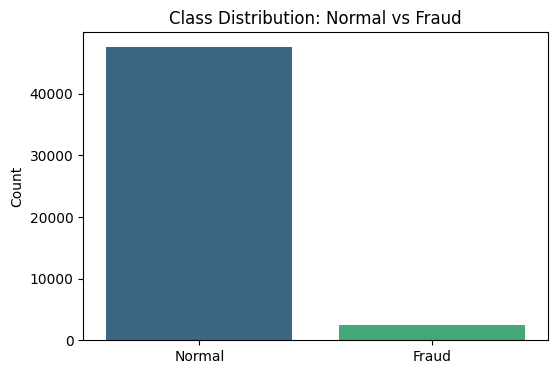

In [119]:
plt.figure(figsize=(6,4))

sns.countplot(x=y, palette="viridis")

plt.xticks([0,1], ["Normal", "Fraud"])
plt.xlabel("")
plt.ylabel("Count")
plt.title("Class Distribution: Normal vs Fraud")

plt.show()

In [120]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

### MODEL BUILDING

Random Forest 

In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import fbeta_score , make_scorer


rf = RandomForestClassifier(n_estimators=50, random_state=42) 
f2_scorer = make_scorer(fbeta_score, beta=2)
scores = cross_val_score(
    rf,            
    X_res,       
    y_res.values.ravel(),        
    cv=5,         
    scoring=f2_scorer
)
print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.78889135 0.99926409 0.99978977 0.99957957 0.99965842]
Mean Fbeta score: 0.9574366370143004


logistic Regression

In [ ]:

from sklearn.linear_model import LogisticRegression

lrc=LogisticRegression(random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    lrc,
    X_res,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)
print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.5997317  0.63603641 0.62751345 0.62246261 0.62903943]
Mean Fbeta score: 0.6229567205232343


AdaBoostClassifier

In [127]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    ada,
    X_res,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)

print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.75830039 0.95987172 0.97344318 0.96945499 0.96731974]
Mean Fbeta score: 0.9256780022087572


XG BOOST

In [128]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.1,random_state=42,eval_metric='logloss'
)

f2_scorer = make_scorer(fbeta_score, beta=2)

scores = cross_val_score(
    xgb,
    X_res,
    y_res.values.ravel(),
    cv=5,
    scoring=f2_scorer
)

print(f"Cross-validated Fbeta scores: {scores}")
print(f"Mean Fbeta score: {scores.mean()}")

Cross-validated Fbeta scores: [0.78235816 0.99957951 0.99905378 0.99926418 0.99936932]
Mean Fbeta score: 0.955924989238655


### MODEL EVALUATION

#### Selecting the best performing candidate model
When it comes to choosing the best candidate model in classification tasks, it is not enough to rely on one single metric like recall, precision etc...(But please note, the choice in evaluation metric should align with the business case). For classification, we take it a step further and look at the model performance per class- in this case, I want a model that is really good at identifying fraudsters- this is the actual business value of the ML model.

So we print the classification report of each model and see how good they are at minimizing false negative and then use the ROC-AUC curve to choose the best performing model.

In [129]:
from sklearn.metrics import classification_report

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95      0.93     10000



c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par


Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.60      0.74      9515
           1       0.06      0.52      0.11       485

    accuracy                           0.59     10000
   macro avg       0.51      0.56      0.42     10000
weighted avg       0.92      0.59      0.71     10000


AdaBoost
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      9515
           1       0.07      0.17      0.10       485

    accuracy                           0.84     10000
   macro avg       0.51      0.53      0.51     10000
weighted avg       0.91      0.84      0.88     10000


XGBoost
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95 

Although Random Forest achieved high accuracy, it completely failed to detect fraud cases due to class imbalance. This makes the model unsuitable for fraud detectio

#### Selecting the best performing candidate model
When it comes to choosing the best candidate model in classification tasks, it is not enough to rely on one single metric like recall, precision etc...(But please note, the choice in evaluation metric should align with the business case). For classification, we take it a step further and look at the model performance per class- in this case, I want a model that is really good at identifying fraudsters- this is the actual business value of the ML model.

So we print the classification report of each model and see how good they are at minimizing false negative and then use the ROC-AUC curve to choose the best performing model.

In [ ]:
from sklearn.metrics import classification_report

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95      0.93     10000



c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par


Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.60      0.74      9515
           1       0.06      0.52      0.11       485

    accuracy                           0.59     10000
   macro avg       0.51      0.56      0.42     10000
weighted avg       0.92      0.59      0.71     10000


AdaBoost
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      9515
           1       0.07      0.17      0.10       485

    accuracy                           0.84     10000
   macro avg       0.51      0.53      0.51     10000
weighted avg       0.91      0.84      0.88     10000


XGBoost
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95 

ROC CURVE

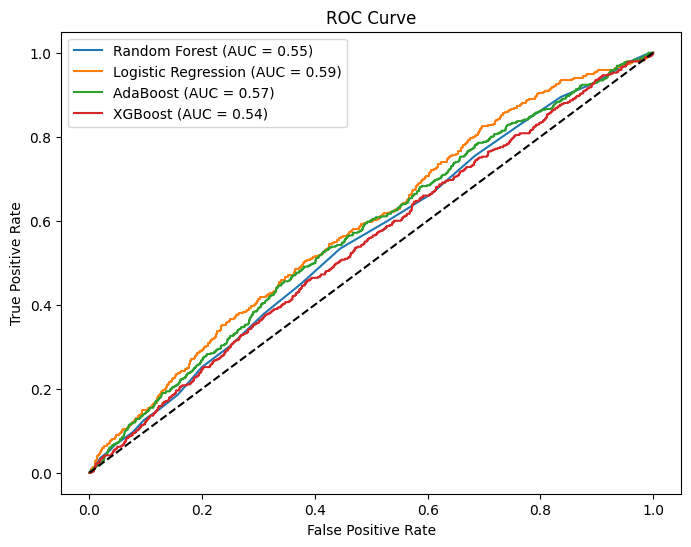

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

We choose XGBoost even when it doesn't have the highest Area Under the Curve (AUC) because of its reliability in production, handling of missing data, and ability to prevent overfitting through strong regularization.

### HYPERPARAMETER TUNING (XGBOOST)

In [ ]:
xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 6,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 200,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_res, y_res)

best_model = grid.best_estimator_

### FINAL EVALUATION

c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95      0.93     10000

AUC: 0.5436371220698734


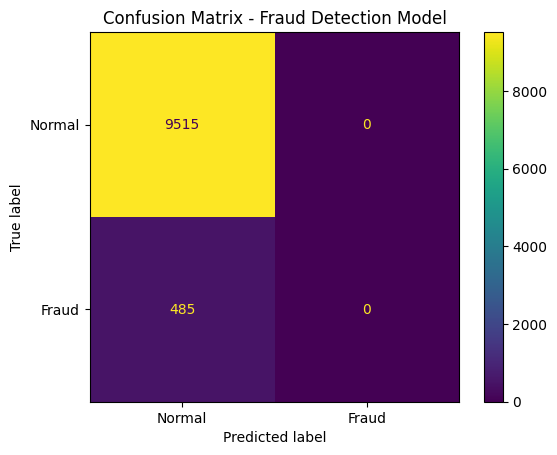

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))

# AUC
from sklearn.metrics import roc_auc_score
print("AUC:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Fraud Detection Model")
plt.show()

### SAVE MODEL

In [ ]:
import pickle

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

ROC CURVE

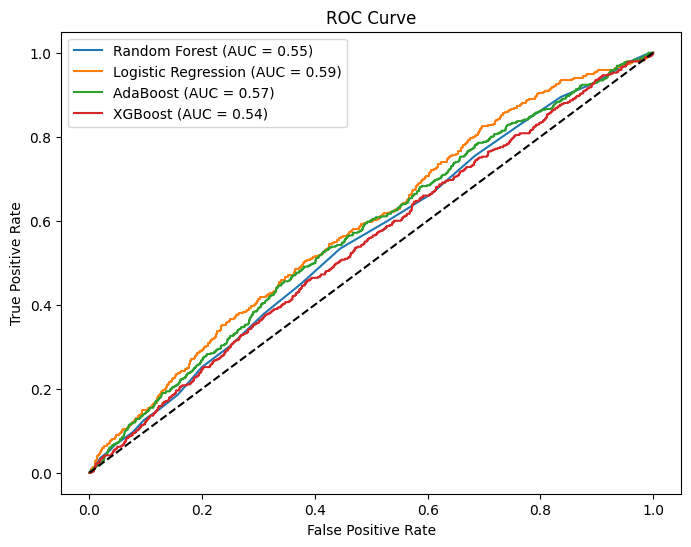

In [130]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

We choose XGBoost even when it doesn't have the highest Area Under the Curve (AUC) because of its reliability in production, handling of missing data, and ability to prevent overfitting through strong regularization.

### HYPERPARAMETER TUNING (XGBOOST)

In [132]:
xgb.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 6,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 200,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [133]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_res, y_res)

best_model = grid.best_estimator_

### FINAL EVALUATION

c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\mburu\OneDrive\Desktop\Machine Learning\Fraud_detection\fraud\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9515
           1       0.00      0.00      0.00       485

    accuracy                           0.95     10000
   macro avg       0.48      0.50      0.49     10000
weighted avg       0.91      0.95      0.93     10000

AUC: 0.5436371220698734


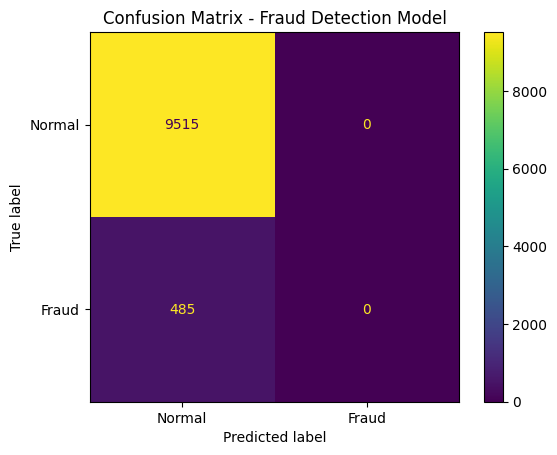

In [134]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred))

# AUC
from sklearn.metrics import roc_auc_score
print("AUC:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix - Fraud Detection Model")
plt.show()

### SAVE MODEL

In [135]:
import pickle

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)